# F129 synthetic images with image positions

Unpickles the step-02 `GalaxyGalaxy` objects for rung 0, renders each one in F129 the way
step 04 does (same FOV, numerics, and cached STPSF kernel), and lays 100 of them out in a
10x10 grid on a log stretch with the image positions overplotted.

Image positions come from `SyntheticImage.get_image_positions()`, which solves the lens
equation with `GalaxyGalaxy.get_image_positions()` and maps the result onto this image's
pixel grid.

In [1]:
import hashlib
import os
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import yaml
from matplotlib.colors import LogNorm
from tqdm import tqdm

import mejiro
from mejiro.instruments.roman import Roman
from mejiro.synthetic_image import SyntheticImage
from mejiro.utils import roman_util, util
from mejiro.utils.pipeline_helper import PipelineHelper

# the step-02 pickles embed mejiro-v2 astropy objects; the pipeline scripts apply this
# patch before unpickling, so mirror it here
PipelineHelper.patch_astropy_for_mejiro_v2_pickles()

config_file = os.path.join(os.path.dirname(os.path.dirname(mejiro.__file__)), 'projects', 'roman_data_challenge', 'roman_data_challenge_rung_0.yaml')
with open(config_file, 'r') as f:
    config = yaml.load(f, Loader=yaml.SafeLoader)

## The step-02 pickles

Every SCA gets its own subdirectory, so glob across all of them and draw the sample from
the whole population rather than from one detector.

In [2]:
lens_dir = '/data2/bwedig/mejiro/roman_data_challenge_rung_0/02'  # TODO update this path!
band = 'F129'
nrows, ncols = 10, 10
n_panels = nrows * ncols
sample_seed = 42

pickles = sorted(glob(os.path.join(lens_dir, 'sca*', '*.pkl')))
print(f'Found {len(pickles)} system(s) in {lens_dir}')

# shuffle so the grid samples every SCA rather than the first few hundred uids on sca01
rng = np.random.default_rng(sample_seed)
candidates = [pickles[i] for i in rng.permutation(len(pickles))]

Found 11179 system(s) in /data2/bwedig/mejiro/roman_data_challenge_rung_0/02


## Rendering

Each system is rendered with the step-04 settings out of the config: the same FOV,
supersampling, and the STPSF kernel cached for its SCA and detector position. The detector
position is the same md5-of-`seed`-and-name draw `_04_create_synthetic_images` makes, so a
system gets the kernel it was convolved with in the pipeline.

JAXtronomy is off by default: it pays an XLA compile per lens, which dominates the runtime
for a hundred one-off renders. Set `use_jax = True` to match the pipeline exactly.

In [3]:
use_jax = False

synthetic_image_config = config['synthetic_image']
psf_config = config['psf']
fov_arcsec = synthetic_image_config['fov_arcsec']
# step 04 renders at supersampling_factor 5, which costs ~2 minutes per system (see the
# step-04 entry in execution_times.json); 1 is seconds per system and looks the same at this
# panel size. Set it to synthetic_image_config['supersampling_factor'] to match the pipeline.
supersampling_factor = 1
num_pix = psf_config['num_pixes'][0]
possible_detector_positions = roman_util.divide_up_sca(psf_config['divide_up_detector'])
psf_cache_dir = os.path.join(config['data_dir'], config['psf_cache_dir'])

kwargs_numerics = {
    'supersampling_factor': supersampling_factor,
    'compute_mode': synthetic_image_config['supersampling_compute_mode'],
}

instrument = Roman()


def detector_position(name):
    """The detector position, and hence the PSF, step 04 assigns this system."""
    h = hashlib.md5(f"{config['seed']}_detector_position_{name}".encode()).hexdigest()
    return possible_detector_positions[int(h[:8], 16) % len(possible_detector_positions)]


def render(pickle_path):
    lens = util.unpickle(pickle_path)
    if not use_jax:
        lens.use_jax = [False] * len(lens.lens_model_list)

    instrument_params = {
        # the sca* directory names are lowercase; get_sca_int only strips an uppercase 'SCA'
        'detector': roman_util.get_sca_int(os.path.basename(os.path.dirname(pickle_path)).upper()),
        'detector_position': detector_position(lens.name),
    }
    kwargs_psf = instrument.get_psf_kwargs(band=band,
                                           oversample=supersampling_factor,
                                           num_pix=num_pix,
                                           check_cache=True,
                                           psf_cache_dir=psf_cache_dir,
                                           require_cached=True,
                                           degrade=True,
                                           **instrument_params)

    return SyntheticImage(strong_lens=lens,
                          instrument=instrument,
                          band=band,
                          fov_arcsec=fov_arcsec,
                          instrument_params=instrument_params,
                          kwargs_numerics=kwargs_numerics,
                          kwargs_psf=kwargs_psf,
                          pieces=False)

In [4]:
panels = []  # (SyntheticImage, x_pix, y_pix) per system
failures = []

max_consecutive_failures = 10  # a systematic error should surface in seconds, not minutes
consecutive_failures = 0

progress = tqdm(total=n_panels)
for pickle_path in candidates:
    if len(panels) == n_panels:
        break
    if consecutive_failures >= max_consecutive_failures:
        raise RuntimeError(f'{consecutive_failures} consecutive failures, aborting: {failures[-1]}')
    try:
        synthetic_image = render(pickle_path)
        # pixel coordinates on this image's grid, so they can be scattered on top of the array
        x_pix, y_pix = synthetic_image.get_image_positions(pixel=True)
    except Exception as e:
        failures.append((os.path.basename(pickle_path), repr(e)))
        consecutive_failures += 1
        continue
    consecutive_failures = 0
    panels.append((synthetic_image, np.atleast_1d(x_pix), np.atleast_1d(y_pix)))
    progress.update(1)
progress.close()

print(f'Rendered {len(panels)} system(s); {len(failures)} failure(s)')
for name, error in failures[:10]:
    print(f'  {name}: {error}')

  0%|          | 0/100 [00:00<?, ?it/s]**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-072 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-073
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf
/grad/bwedig/mejiro/mejiro/synthetic_image.py:243: UserWarning: Supersampling factor less than 5 may not be sufficient for accurate results, especially when convolving with a non-trivial PSF
  warnings.warn('Supersampling factor less than 5 may not be sufficient for accurate results, especially when convolving with a non-trivial PSF')
100%|██████████| 100/100 [00:25<00:00,  3.93it/s]

Rendered 100 system(s); 0 failure(s)


## The grid

Every panel is stretched independently over `dynamic_range` decades below its own peak, in
counts/sec. Crosses mark the image positions; a system whose images fall outside the FOV
will show fewer crosses than it has images (see `check_large_theta_E_systems.ipynb`).

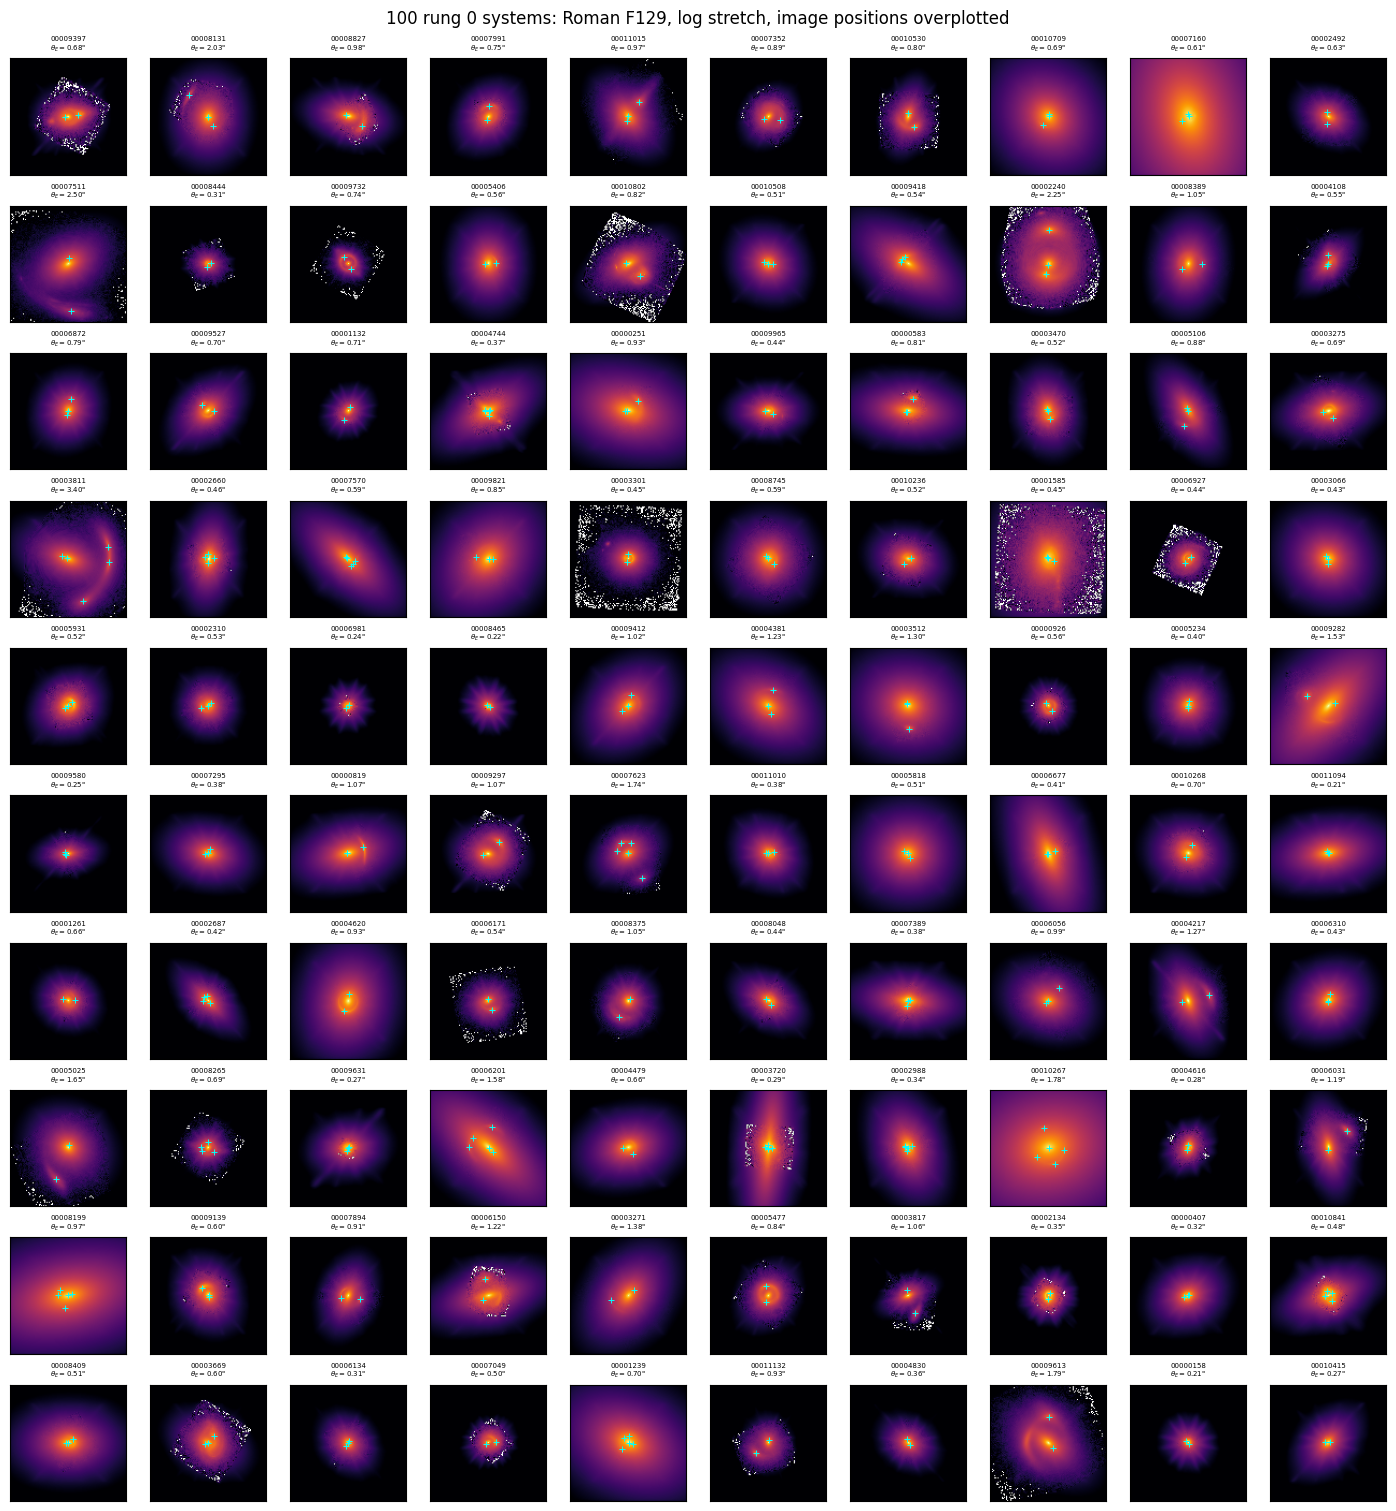

In [5]:
dynamic_range = 1e4  # decades of counts/sec shown below each panel's peak
cmap = 'inferno'

fig, axes = plt.subplots(nrows, ncols, figsize=(1.4 * ncols, 1.5 * nrows), constrained_layout=True, squeeze=False)

for ax, (synthetic_image, x_pix, y_pix) in zip(axes.flat, panels):
    data = synthetic_image.data
    vmax = float(np.max(data))
    ax.imshow(data, origin='lower', cmap=cmap, norm=LogNorm(vmin=vmax / dynamic_range, vmax=vmax))

    # keep the axes on the image: positions outside the FOV would otherwise rescale the panel
    num_pix_panel = data.shape[0]
    on_fov = (x_pix >= 0) & (x_pix <= num_pix_panel - 1) & (y_pix >= 0) & (y_pix <= num_pix_panel - 1)
    ax.scatter(x_pix[on_fov], y_pix[on_fov], marker='+', s=18, linewidths=0.7, color='cyan')

    ax.set_title(f'{synthetic_image.strong_lens.name.split("_")[-1]}\n' + r'$\theta_E=$' + f'{synthetic_image.strong_lens.get_einstein_radius():.2f}"', fontsize=5)

# blank any leftover panels
for ax in axes.flat[len(panels):]:
    ax.set_visible(False)

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f'{len(panels)} rung 0 systems: Roman {band}, log stretch, image positions overplotted')

os.makedirs('figures/02', exist_ok=True)
plt.savefig(f'figures/02/{band.lower()}_image_position_grid.png', dpi=300)
plt.show()